# CDT-II: GFI1B Subnetwork Visualization (Figure 5)

## Goal
Create a radial network visualization showing GFI1B's regulatory network with bidirectional relationships
- GFI1B as central hub (red)
- Downstream targets: GFI1B → gene (blue)
- Upstream regulators: gene → GFI1B (orange)
- Bidirectional: mutual attention (purple)
- Edge thickness proportional to attention weight

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install h5py tqdm scipy networkx -q

import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

print("Imports successful!")

Imports successful!


In [ ]:
# Paths - Stage 1.5
DRIVE_BASE = Path("/content/drive/MyDrive/cdt_data")
MODEL_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5")
OUTPUT_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

TSS_EFFECTS_PATH = DRIVE_BASE / "morris_celllevel_effects_2361.h5"
TSS_ENFORMER_PATH = DRIVE_BASE / "morris_28genes_enformer.h5"
MODEL_PATH = MODEL_BASE / "cdt_morris_celllevel_best.pt"

print("Checking files...")
for name, path in [
    ("Cell-level effects (2361)", TSS_EFFECTS_PATH),
    ("Enformer embeddings", TSS_ENFORMER_PATH),
    ("Model (Stage 1.5)", MODEL_PATH),
]:
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  [{status}] {name}")

Checking files...
  [OK] Cell-level effects (2361)
  [OK] Enformer embeddings
  [OK] Model (Stage 1.5)


## 2. Load Data

In [ ]:
# Load cell-level effects
with h5py.File(TSS_EFFECTS_PATH, 'r') as f:
    tss_log2fc = f['log2fc'][:]
    tss_cell_expr = f['cell_expr'][:]
    tss_target_gene_idx = f['target_gene_idx'][:]
    tss_target_gene_names = [g.decode() if isinstance(g, bytes) else g
                             for g in f['target_gene_names'][:]]
    # Load 2361 gene list
    cdt_genes = [g.decode() if isinstance(g, bytes) else g
                 for g in f['gene_names_cdt'][:]]

N_GENES = len(cdt_genes)
gene_to_idx = {g: i for i, g in enumerate(cdt_genes)}

print(f"CDT genes: {N_GENES}")
print(f"Cells: {tss_log2fc.shape[0]}")
print(f"GFI1B in gene list: {'GFI1B' in gene_to_idx}")
if 'GFI1B' in gene_to_idx:
    print(f"GFI1B index: {gene_to_idx['GFI1B']}")

# Load Enformer embeddings
with h5py.File(TSS_ENFORMER_PATH, 'r') as f:
    tss_enformer_emb = f['embeddings'][:]
    tss_enformer_genes = [g.decode() if isinstance(g, bytes) else g
                          for g in f['gene_names'][:]]
tss_gene_to_enformer = {gene: i for i, gene in enumerate(tss_enformer_genes)}
print(f"Enformer genes: {len(tss_enformer_genes)}")

CDT genes: 2361
Cells: 8250
GFI1B in gene list: True
GFI1B index: 2360
Enformer genes: 28


## 3. Model Definition

In [ ]:
@dataclass
class CDTCRISPRiConfig:
    dna_dim: int = 3072
    dna_seq_len: int = 896
    n_genes: int = 2361
    hidden_dim: int = 512
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1


class RawExpressionEncoder(nn.Module):
    def __init__(self, n_genes, hidden_dim, dropout=0.1):
        super().__init__()
        self.n_genes = n_genes
        self.hidden_dim = hidden_dim
        self.gene_embedding = nn.Embedding(n_genes, hidden_dim)
        self.expr_projector = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout)
        )
        self.combine = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LayerNorm(hidden_dim), nn.Dropout(dropout)
        )

    def forward(self, expression):
        batch_size = expression.size(0)
        device = expression.device
        gene_ids = torch.arange(self.n_genes, device=device)
        gene_emb = self.gene_embedding(gene_ids).unsqueeze(0).expand(batch_size, -1, -1)
        expr_emb = self.expr_projector(expression.unsqueeze(-1))
        combined = torch.cat([gene_emb, expr_emb], dim=-1)
        return self.combine(combined)


class SequenceProjector(nn.Module):
    def __init__(self, input_dim, output_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.norm(self.linear(x)))


class FlashSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        batch_size, seq_len, _ = x.shape
        Q = self.q_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)

        if return_attention:
            scale = self.head_dim ** -0.5
            attn_weights = torch.matmul(Q, K.transpose(-2, -1)) * scale
            attn_weights = F.softmax(attn_weights, dim=-1)
            attn_out = torch.matmul(attn_weights, V)
        else:
            attn_out = F.scaled_dot_product_attention(Q, K, V, dropout_p=self.dropout_p if self.training else 0.0)
            attn_weights = None

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))

        if return_attention:
            return x, attn_weights
        return x


class FlashCrossAttentionBlock(nn.Module):
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value):
        batch_size, query_len, _ = query.shape
        key_len = key_value.shape[1]
        Q = self.q_proj(query).view(batch_size, query_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V, dropout_p=self.dropout_p if self.training else 0.0)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, query_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x


class VirtualCellEmbedderDNARNA(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = 4
        self.head_dim = d_model // self.nhead
        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.dna_q_proj = nn.Linear(d_model, d_model)
        self.dna_k_proj = nn.Linear(d_model, d_model)
        self.dna_v_proj = nn.Linear(d_model, d_model)
        self.dna_out_proj = nn.Linear(d_model, d_model)
        self.rna_q_proj = nn.Linear(d_model, d_model)
        self.rna_k_proj = nn.Linear(d_model, d_model)
        self.rna_v_proj = nn.Linear(d_model, d_model)
        self.rna_out_proj = nn.Linear(d_model, d_model)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.LayerNorm(d_model)
        )

    def _attention_pool(self, query, key_value, q_proj, k_proj, v_proj, out_proj):
        batch_size = key_value.size(0)
        seq_len = key_value.size(1)
        query = query.expand(batch_size, -1, -1)
        Q = q_proj(query).view(batch_size, 1, self.nhead, self.head_dim).transpose(1, 2)
        K = k_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = v_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, 1, self.d_model)
        return out_proj(attn_out).squeeze(1)

    def forward(self, dna_encoded, rna_encoded):
        dna_pooled = self._attention_pool(
            self.dna_query, dna_encoded,
            self.dna_q_proj, self.dna_k_proj, self.dna_v_proj, self.dna_out_proj
        )
        rna_pooled = self._attention_pool(
            self.rna_query, rna_encoded,
            self.rna_q_proj, self.rna_k_proj, self.rna_v_proj, self.rna_out_proj
        )
        concat = torch.cat([dna_pooled, rna_pooled], dim=-1)
        return self.fusion(concat)


class CDTCRISPRiModel(nn.Module):
    def __init__(self, config=None):
        super().__init__()
        if config is None:
            config = CDTCRISPRiConfig()
        self.config = config
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.dna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.dna_self_attn_layers)
        ])
        self.rna_encoder = RawExpressionEncoder(config.n_genes, config.hidden_dim, config.dropout)
        self.rna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.rna_self_attn_layers)
        ])
        self.dna_to_rna = FlashCrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
        self.vce = VirtualCellEmbedderDNARNA(config.hidden_dim, config.dropout)
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim), nn.GELU(), nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_genes)
        )

    def forward(self, dna_emb, rna_expr):
        dna = self.dna_projector(dna_emb)
        rna = self.rna_encoder(rna_expr)
        for layer in self.dna_self_attn_layers:
            dna = layer(dna)
        for layer in self.rna_self_attn_layers:
            rna = layer(rna)
        rna = self.dna_to_rna(query=rna, key_value=dna)
        cell_embedding = self.vce(dna, rna)
        effect = self.task_layer(cell_embedding)
        return effect

print("Model defined!")

Model defined!


In [ ]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

config = CDTCRISPRiConfig()
model = CDTCRISPRiModel(config).to(device)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()
print("Model loaded!")

Device: cuda
Model loaded!


## 4. Extract GFI1B Attention

In [ ]:
# Get GFI1B cells
gfi1b_gene_idx_in_target = tss_target_gene_names.index('GFI1B')
gfi1b_cell_mask = tss_target_gene_idx == gfi1b_gene_idx_in_target
gfi1b_cell_indices = np.where(gfi1b_cell_mask)[0]
print(f"GFI1B cells: {len(gfi1b_cell_indices)}")

# GFI1B DNA embedding
gfi1b_dna_idx = tss_gene_to_enformer['GFI1B']
gfi1b_dna = tss_enformer_emb[gfi1b_dna_idx]  # [896, 3072]

GFI1B cells: 477


In [ ]:
# Extract RNA Self-Attention for GFI1B cells
print("Extracting RNA Self-Attention for GFI1B cells...")

n_sample = min(50, len(gfi1b_cell_indices))  # Sample cells
sample_indices = gfi1b_cell_indices[:n_sample]

rna_self_attns = []

for ci in tqdm(sample_indices, desc="Extracting attention"):
    dna_t = torch.from_numpy(gfi1b_dna.astype(np.float32)).unsqueeze(0).to(device)
    rna_t = torch.from_numpy(tss_cell_expr[ci].astype(np.float32)).unsqueeze(0).to(device)

    with torch.no_grad():
        dna_enc = model.dna_projector(dna_t)
        rna_enc = model.rna_encoder(rna_t)

        for layer in model.dna_self_attn_layers:
            dna_enc = layer(dna_enc)

        # Manual attention extraction for RNA self-attention
        rna_layer = model.rna_self_attn_layers[0]
        batch_size, seq_len, _ = rna_enc.shape
        Q = rna_layer.q_proj(rna_enc).view(batch_size, seq_len, rna_layer.nhead, rna_layer.head_dim).transpose(1, 2)
        K = rna_layer.k_proj(rna_enc).view(batch_size, seq_len, rna_layer.nhead, rna_layer.head_dim).transpose(1, 2)
        scale = rna_layer.head_dim ** -0.5
        attn = torch.matmul(Q, K.transpose(-2, -1)) * scale
        attn = F.softmax(attn, dim=-1)
        rna_self_attns.append(attn[0].cpu().numpy())

# Average across cells and heads
rna_self_attn_avg = np.mean(rna_self_attns, axis=0)  # [nhead, n_genes, n_genes]
attn_matrix = rna_self_attn_avg.mean(axis=0)  # [n_genes, n_genes]

# Remove self-loops
np.fill_diagonal(attn_matrix, 0)

print(f"Attention matrix shape: {attn_matrix.shape}")

Extracting RNA Self-Attention for GFI1B cells...


Extracting attention: 100%|██████████| 50/50 [00:07<00:00,  6.98it/s]


Attention matrix shape: (2361, 2361)


## 5. Analyze Bidirectional Attention

In [ ]:
# GFI1B index in CDT gene list
gfi1b_idx = gene_to_idx.get('GFI1B')
print(f"GFI1B index: {gfi1b_idx}")

# Bidirectional attention profiles
# Downstream: GFI1B -> targets (row = what GFI1B attends to)
gfi1b_to_others = attn_matrix[gfi1b_idx, :].copy()
gfi1b_to_others[gfi1b_idx] = 0  # Remove self

# Upstream: targets -> GFI1B (column = what attends to GFI1B)
others_to_gfi1b = attn_matrix[:, gfi1b_idx].copy()
others_to_gfi1b[gfi1b_idx] = 0  # Remove self

print(f"\nDownstream (GFI1B->): max={gfi1b_to_others.max():.4f}, mean={gfi1b_to_others.mean():.6f}")
print(f"Upstream (->GFI1B): max={others_to_gfi1b.max():.4f}, mean={others_to_gfi1b.mean():.6f}")

GFI1B index: 2360

Downstream (GFI1B->): max=0.1068, mean=0.000423
Upstream (->GFI1B): max=0.0010, mean=0.000105


In [ ]:
# Define thresholds for edges (top 5% percentile)
PERCENTILE = 95

downstream_threshold = np.percentile(gfi1b_to_others[gfi1b_to_others > 0], PERCENTILE)
upstream_threshold = np.percentile(others_to_gfi1b[others_to_gfi1b > 0], PERCENTILE)

print(f"Downstream threshold (top 5%): {downstream_threshold:.6f}")
print(f"Upstream threshold (top 5%): {upstream_threshold:.6f}")

# Classify genes
downstream_genes = []  # GFI1B -> gene (high downstream, low upstream)
upstream_genes = []    # gene -> GFI1B (low downstream, high upstream)
bidirectional_genes = []  # both directions

for i in range(N_GENES):
    if i == gfi1b_idx:
        continue

    is_downstream = gfi1b_to_others[i] >= downstream_threshold
    is_upstream = others_to_gfi1b[i] >= upstream_threshold

    if is_downstream and is_upstream:
        bidirectional_genes.append(i)
    elif is_downstream:
        downstream_genes.append(i)
    elif is_upstream:
        upstream_genes.append(i)

print(f"\nClassification (top 5% edges):")
print(f"  Downstream only (GFI1B->): {len(downstream_genes)}")
print(f"  Upstream only (->GFI1B): {len(upstream_genes)}")
print(f"  Bidirectional: {len(bidirectional_genes)}")

Downstream threshold (top 5%): 0.001365
Upstream threshold (top 5%): 0.000376

Classification (top 5% edges):
  Downstream only (GFI1B->): 85
  Upstream only (->GFI1B): 85
  Bidirectional: 33


In [ ]:
# Print top genes in each category
print("\nTop Downstream targets (GFI1B->):")
sorted_downstream = sorted(downstream_genes, key=lambda x: gfi1b_to_others[x], reverse=True)
for i, idx in enumerate(sorted_downstream[:10]):
    print(f"  {i+1}. {cdt_genes[idx]:<12} attn={gfi1b_to_others[idx]:.4f}")

print("\nTop Upstream regulators (->GFI1B):")
sorted_upstream = sorted(upstream_genes, key=lambda x: others_to_gfi1b[x], reverse=True)
for i, idx in enumerate(sorted_upstream[:10]):
    print(f"  {i+1}. {cdt_genes[idx]:<12} attn={others_to_gfi1b[idx]:.4f}")

print("\nBidirectional genes:")
sorted_bidirectional = sorted(bidirectional_genes,
                               key=lambda x: gfi1b_to_others[x] + others_to_gfi1b[x],
                               reverse=True)
for i, idx in enumerate(sorted_bidirectional[:10]):
    print(f"  {i+1}. {cdt_genes[idx]:<12} down={gfi1b_to_others[idx]:.4f} up={others_to_gfi1b[idx]:.4f}")


Top Downstream targets (GFI1B->):
  1. PRRC2C       attn=0.1068
  2. GNG5         attn=0.0511
  3. CDCA8        attn=0.0347
  4. MAGOH        attn=0.0291
  5. SFPQ         attn=0.0179
  6. CDC42        attn=0.0129
  7. KRTCAP2      attn=0.0084
  8. KIF2C        attn=0.0074
  9. ATP5PB       attn=0.0050
  10. CCT4         attn=0.0049

Top Upstream regulators (->GFI1B):
  1. TXNIP        attn=0.0010
  2. DESI2        attn=0.0008
  3. EPB41        attn=0.0007
  4. GLRX2        attn=0.0006
  5. SUCLG1       attn=0.0006
  6. RBBP4        attn=0.0006
  7. UCK2         attn=0.0006
  8. PITHD1       attn=0.0006
  9. RSRP1        attn=0.0006
  10. CAPZB        attn=0.0005

Bidirectional genes:
  1. TAGLN2       down=0.0450 up=0.0004
  2. SF3B6        down=0.0194 up=0.0004
  3. PSMA5        down=0.0165 up=0.0005
  4. C1orf52      down=0.0080 up=0.0004
  5. TMSB10       down=0.0068 up=0.0005
  6. ENO1         down=0.0047 up=0.0005
  7. ZBTB8OS      down=0.0031 up=0.0005
  8. SRP9         down=0.

## 6. Create Radial Network with Bidirectional Edges

In [ ]:
# Select genes for visualization (LIMIT to keep figure clean)
TOP_DOWNSTREAM = 15
TOP_UPSTREAM = 5
TOP_BIDIRECTIONAL = 5

vis_downstream = sorted_downstream[:TOP_DOWNSTREAM]
vis_upstream = sorted_upstream[:TOP_UPSTREAM]
vis_bidirectional = sorted_bidirectional[:TOP_BIDIRECTIONAL]

# Combine all genes (avoid duplicates)
all_vis_genes = list(set(vis_downstream + vis_upstream + vis_bidirectional))

print(f"Visualization genes:")
print(f"  Downstream: {len(vis_downstream)}")
print(f"  Upstream: {len(vis_upstream)}")
print(f"  Bidirectional: {len(vis_bidirectional)}")
print(f"  Total unique: {len(all_vis_genes)}")

Visualization genes:
  Downstream: 15
  Upstream: 5
  Bidirectional: 5
  Total unique: 25


In [ ]:
# Create radial layout
def create_radial_layout(center_node, peripheral_nodes):
    """Create positions for radial layout with center node in middle."""
    pos = {center_node: (0, 0)}
    n = len(peripheral_nodes)
    for i, node in enumerate(peripheral_nodes):
        angle = 2 * np.pi * i / n - np.pi / 2  # Start from top
        x = np.cos(angle)
        y = np.sin(angle)
        pos[node] = (x, y)
    return pos

# Create graph
G = nx.DiGraph()

# Add GFI1B as central hub
G.add_node('GFI1B', node_type='hub')

# Add genes and classify
peripheral_names = []
for idx in all_vis_genes:
    name = cdt_genes[idx]

    # Classify
    if idx in vis_bidirectional:
        node_type = 'bidirectional'
    elif idx in vis_upstream:
        node_type = 'upstream'
    else:
        node_type = 'downstream'

    G.add_node(name, node_type=node_type)
    peripheral_names.append(name)

    # Add edges based on type
    if node_type in ['downstream', 'bidirectional']:
        G.add_edge('GFI1B', name, weight=gfi1b_to_others[idx], edge_type='downstream')
    if node_type in ['upstream', 'bidirectional']:
        G.add_edge(name, 'GFI1B', weight=others_to_gfi1b[idx], edge_type='upstream')

# Create layout
pos = create_radial_layout('GFI1B', peripheral_names)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 26 nodes, 30 edges


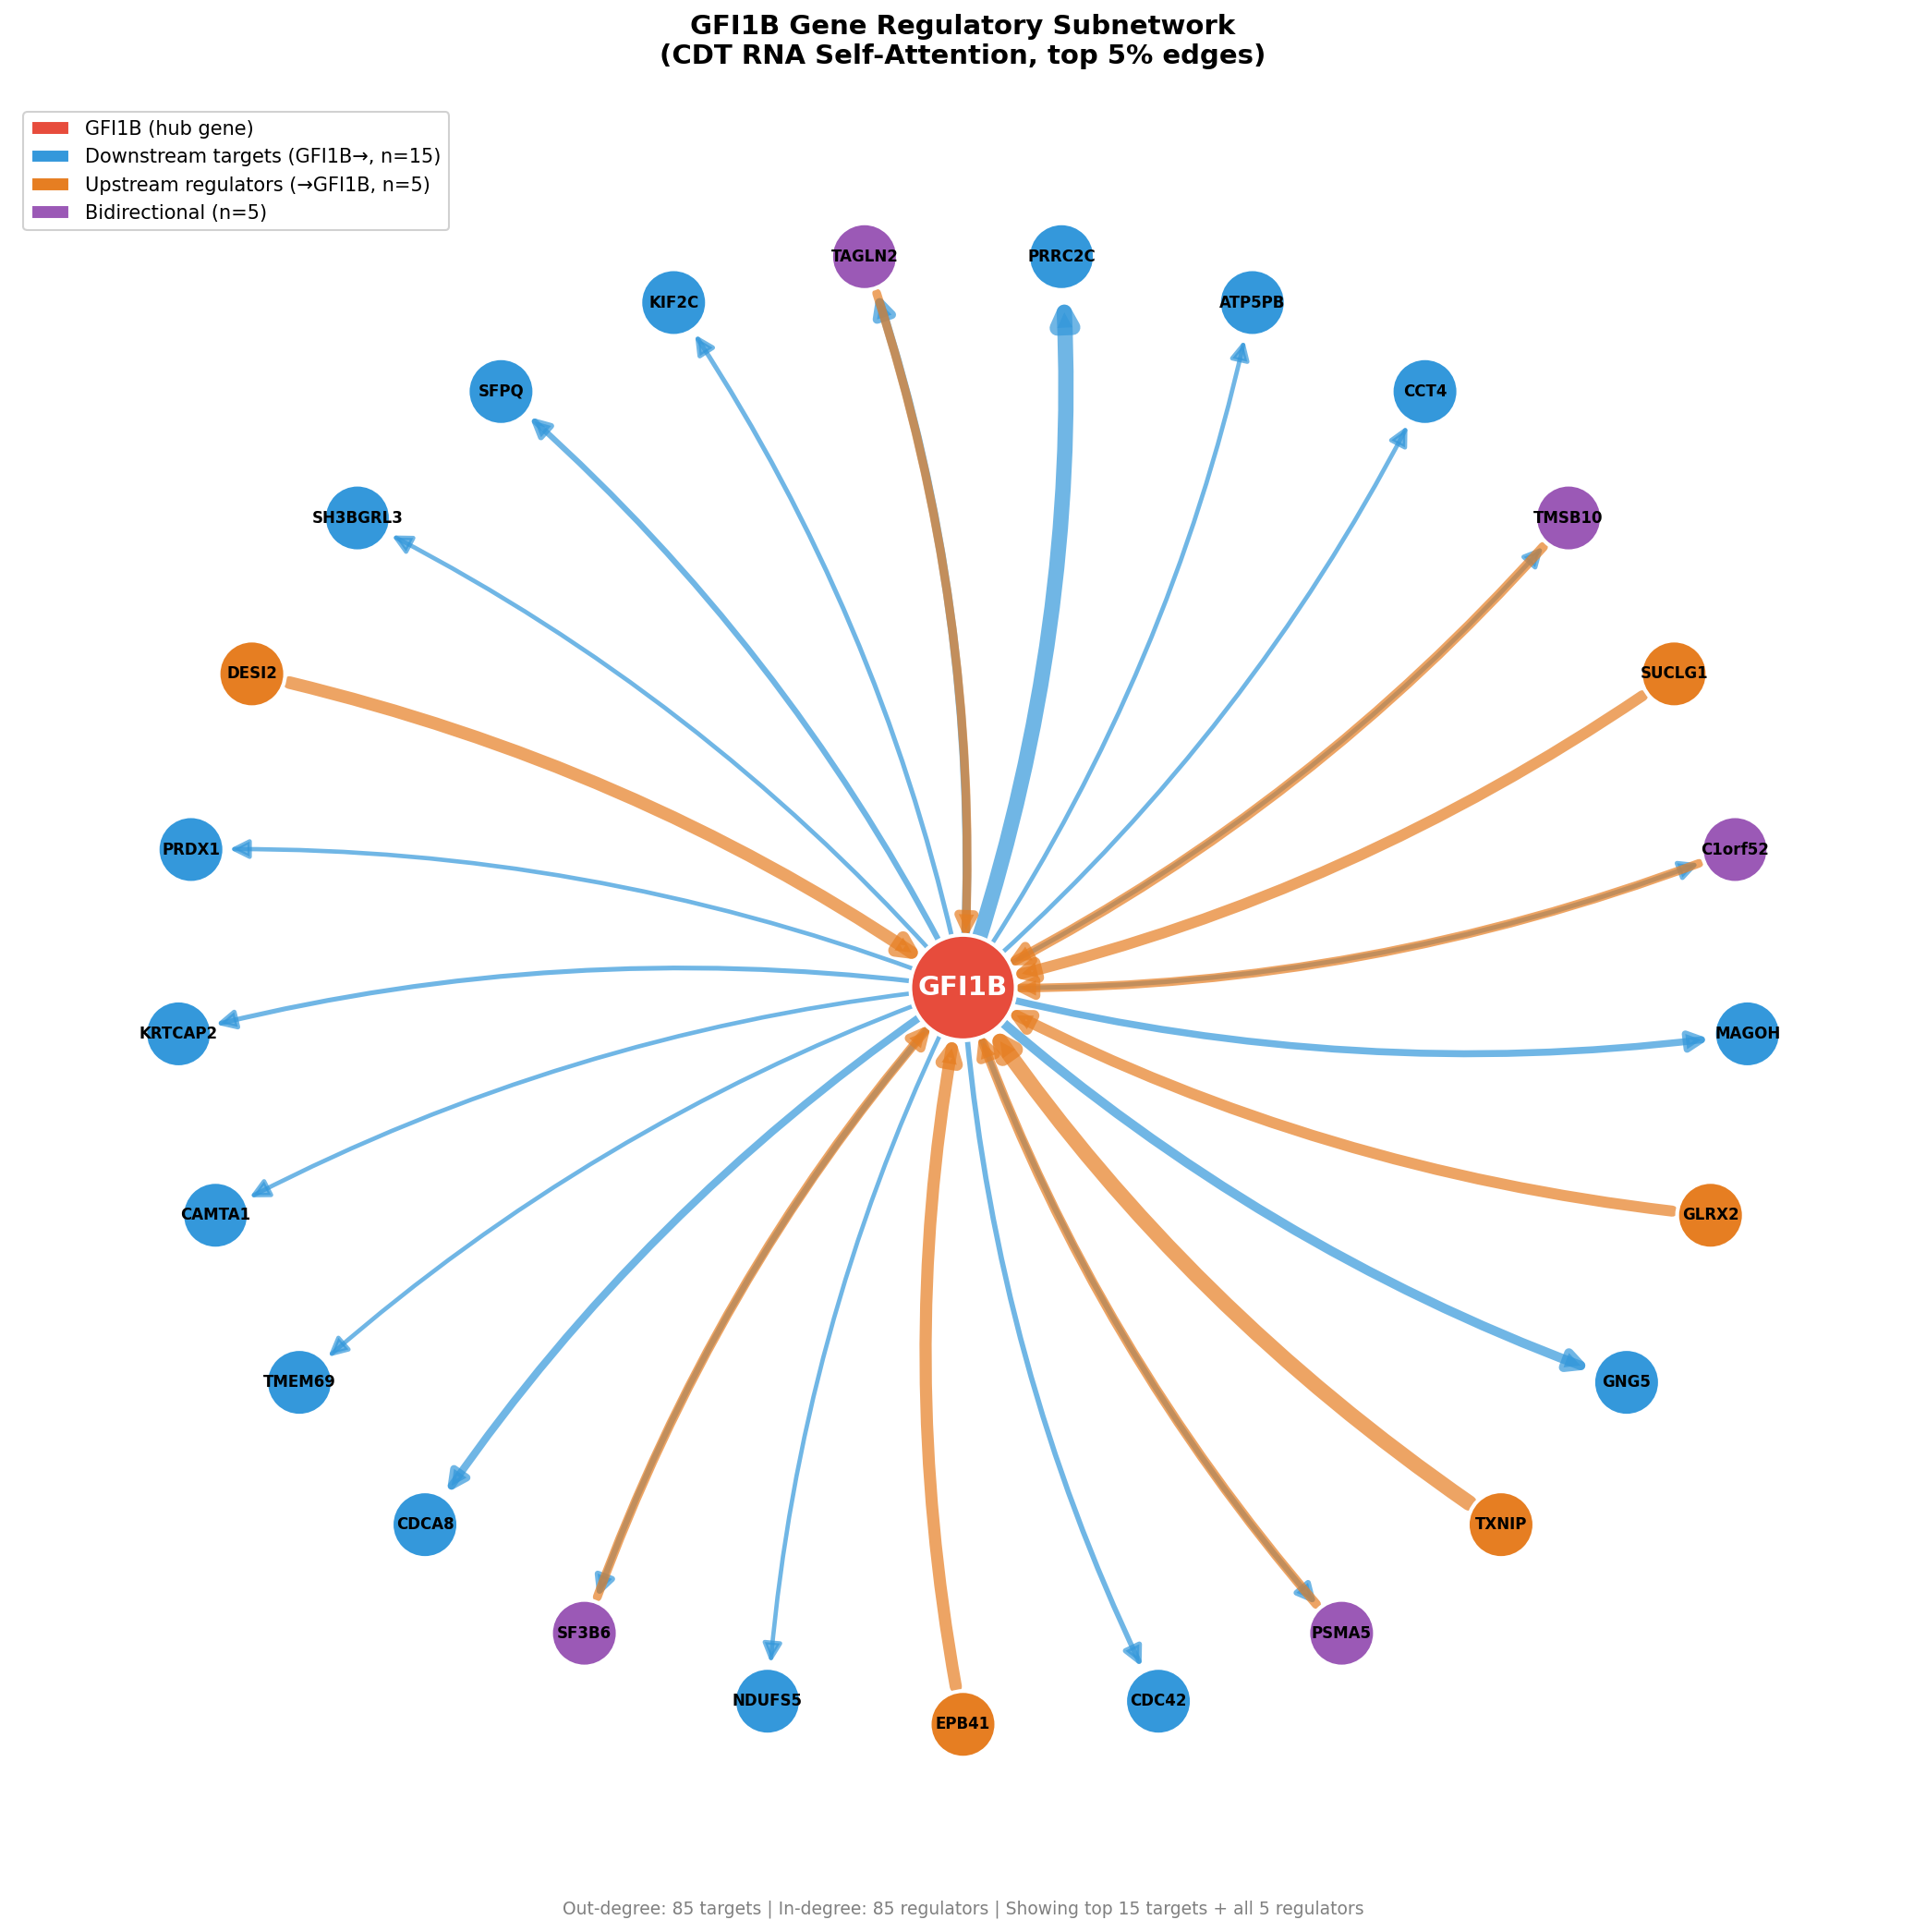


Saved to: fig5_gfi1b_subnetwork.png


In [ ]:
# Create visualization
fig, ax = plt.subplots(figsize=(14, 14), dpi=150)
plt.style.use('default')

# Colors
COLOR_HUB = '#E74C3C'        # Red for GFI1B
COLOR_DOWNSTREAM = '#3498DB'  # Blue for downstream
COLOR_UPSTREAM = '#E67E22'    # Orange for upstream
COLOR_BIDIRECTIONAL = '#9B59B6'  # Purple for bidirectional

# Node colors based on type
node_colors = []
for node in G.nodes():
    node_type = G.nodes[node].get('node_type', 'downstream')
    if node_type == 'hub':
        node_colors.append(COLOR_HUB)
    elif node_type == 'upstream':
        node_colors.append(COLOR_UPSTREAM)
    elif node_type == 'bidirectional':
        node_colors.append(COLOR_BIDIRECTIONAL)
    else:
        node_colors.append(COLOR_DOWNSTREAM)

# Node sizes
node_sizes = [3000 if node == 'GFI1B' else 1200 for node in G.nodes()]

# Draw edges by type
# Downstream edges (GFI1B -> target)
downstream_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'downstream']
downstream_weights = [G[u][v]['weight'] for u, v in downstream_edges]
if downstream_weights:
    max_down = max(downstream_weights)
    downstream_widths = [2 + 6 * (w / max_down) for w in downstream_weights]
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=downstream_edges,
        edge_color=COLOR_DOWNSTREAM,
        width=downstream_widths,
        alpha=0.7,
        arrows=True,
        arrowsize=20,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.1',
        min_source_margin=25,
        min_target_margin=20
    )

# Upstream edges (target -> GFI1B)
upstream_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'upstream']
upstream_weights = [G[u][v]['weight'] for u, v in upstream_edges]
if upstream_weights:
    max_up = max(upstream_weights)
    upstream_widths = [2 + 6 * (w / max_up) for w in upstream_weights]
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=upstream_edges,
        edge_color=COLOR_UPSTREAM,
        width=upstream_widths,
        alpha=0.7,
        arrows=True,
        arrowsize=20,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=-0.1',
        min_source_margin=20,
        min_target_margin=25
    )

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='white',
    linewidths=2
)

# Draw labels
nx.draw_networkx_labels(
    G, pos, ax=ax,
    labels={'GFI1B': 'GFI1B'},
    font_size=14,
    font_weight='bold',
    font_color='white'
)

other_labels = {node: node for node in G.nodes() if node != 'GFI1B'}
nx.draw_networkx_labels(
    G, pos, ax=ax,
    labels=other_labels,
    font_size=8,
    font_weight='bold',
    font_color='black'
)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=COLOR_HUB, edgecolor='white', label='GFI1B (hub gene)'),
    mpatches.Patch(facecolor=COLOR_DOWNSTREAM, edgecolor='white', label=f'Downstream targets (GFI1B→, n={len(vis_downstream)})'),
    mpatches.Patch(facecolor=COLOR_UPSTREAM, edgecolor='white', label=f'Upstream regulators (→GFI1B, n={len(vis_upstream)})'),
    mpatches.Patch(facecolor=COLOR_BIDIRECTIONAL, edgecolor='white', label=f'Bidirectional (n={len(vis_bidirectional)})'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

# Title
ax.set_title('GFI1B Gene Regulatory Subnetwork\n(CDT RNA Self-Attention, top 5% edges)',
             fontsize=14, fontweight='bold', pad=20)

# Footer
n_downstream_total = len(downstream_genes)
n_upstream_total = len(upstream_genes)
ax.text(0.5, -0.02,
        f'Out-degree: {n_downstream_total} targets | In-degree: {n_upstream_total} regulators | '
        f'Showing top {TOP_DOWNSTREAM} targets + all {len(vis_upstream)} regulators',
        transform=ax.transAxes, ha='center', fontsize=9, color='gray')

ax.axis('off')
plt.tight_layout()

# Save
plt.savefig('fig5_gfi1b_subnetwork.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.savefig(OUTPUT_BASE / 'fig5_gfi1b_subnetwork.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f"\nSaved to: fig5_gfi1b_subnetwork.png")

In [ ]:
# Download
from google.colab import files
files.download('fig5_gfi1b_subnetwork.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Summary Statistics

In [ ]:
from scipy.stats import hypergeom

# Experimental effect for enrichment analysis
gfi1b_mean_log2fc = tss_log2fc[gfi1b_cell_mask].mean(axis=0)
experimental_effect_abs = np.abs(gfi1b_mean_log2fc)
exp_ranking = np.argsort(experimental_effect_abs)[::-1]
exp_top100_set = set(exp_ranking[:100])

# Top 100 by attention (downstream)
attn_ranking = np.argsort(gfi1b_to_others)[::-1]
attn_top100_set = set(attn_ranking[:100])

# Overlap
overlap = attn_top100_set & exp_top100_set
n_overlap = len(overlap)
expected = 100 * 100 / N_GENES
enrichment = n_overlap / expected
pval = hypergeom.sf(n_overlap - 1, N_GENES, 100, 100)

print("="*60)
print("GFI1B NETWORK SUMMARY")
print("="*60)
print(f"\nModel: Stage 1.5 (val_r=0.6371)")
print(f"Total CDT genes: {N_GENES}")
print(f"GFI1B cells analyzed: {n_sample}")
print(f"\nNetwork Statistics (top 5% threshold):")
print(f"  Downstream targets (GFI1B->): {len(downstream_genes)}")
print(f"  Upstream regulators (->GFI1B): {len(upstream_genes)}")
print(f"  Bidirectional: {len(bidirectional_genes)}")
print(f"\nTop 100 Enrichment Analysis:")
print(f"  Attention Top 100 ∩ Experimental Top 100: {n_overlap}/100")
print(f"  Expected by chance: {expected:.1f}")
print(f"  Enrichment: {enrichment:.2f}x")
print(f"  P-value: {pval:.2e}")
print(f"\nVisualization:")
print(f"  Downstream shown: {len(vis_downstream)}")
print(f"  Upstream shown: {len(vis_upstream)}")
print(f"  Bidirectional shown: {len(vis_bidirectional)}")

GFI1B NETWORK SUMMARY

Model: Stage 1.5 (val_r=0.6371)
Total CDT genes: 2361
GFI1B cells analyzed: 50

Network Statistics (top 5% threshold):
  Downstream targets (GFI1B->): 85
  Upstream regulators (->GFI1B): 85
  Bidirectional: 33

Top 100 Enrichment Analysis:
  Attention Top 100 ∩ Experimental Top 100: 27/100
  Expected by chance: 4.2
  Enrichment: 6.37x
  P-value: 4.07e-16

Visualization:
  Downstream shown: 15
  Upstream shown: 5
  Bidirectional shown: 5


In [ ]:
print("\nDone!")


Done!
